# Esplorazione e validazione del modello di stima dei tempi di consegna

Notebook a supporto del capstone del Modulo 06 (LogiFast Solutions). Obiettivo:
ispezionare l'artefatto `delivery.pkl` fornito, caratterizzarne il comportamento e
produrre un report di metriche.

**Nota metodologica.** La traccia fornisce il modello ma non un dataset etichettato.
Le metriche di questo notebook sono quindi calcolate su un **dataset sintetico**
generato da un processo documentato (sezione 3): servono a mostrare la *metodologia*
di validazione e a misurare quanto il modello fornito si allinea a una realta'
plausibile, non sono metriche su dati di produzione reali. L'analisi della sezione 2
e' invece intrinseca al modello e non dipende dal sintetico.

## 1. Ispezione dell'artefatto
Cosa e' davvero il modello, prima di usarlo.

In [1]:
%matplotlib inline
import pickle
from pathlib import Path
from math import radians, sin, cos, asin, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(42)

# Risolve l'artefatto sia eseguendo da notebooks/ sia dalla cartella del PRJ.
MODEL_PATH = next(p for p in (Path("delivery.pkl"), Path("..") / "delivery.pkl") if p.exists())
model = pickle.load(open(MODEL_PATH, "rb"))
pre = model.named_steps["preprocess"]
reg = model.named_steps["regressor"]

KNOWN = {}
for _name, enc, cols in pre.transformers_:
    if hasattr(enc, "categories_"):
        for col, cats in zip(cols, enc.categories_):
            KNOWN[col] = list(map(str, cats))

CITIES = KNOWN["pickup_location"]
SERVICES = KNOWN["service_type"]
FEATURES = list(pre.feature_names_in_)

print("Step della pipeline:", [name for name, _ in model.steps])
print("Estimatore finale  :", type(reg).__name__)
print("Feature attese     :", FEATURES)
print("Citta note         :", len(CITIES))
print("Tipi di servizio   :", SERVICES)
print("pickup_datetime usato dal modello?", "pickup_datetime" in FEATURES)
print("intercetta         :", round(float(reg.intercept_), 3))
print("n. feature post-OHE:", reg.n_features_in_)

Step della pipeline: ['preprocess', 'regressor']
Estimatore finale  : LinearRegression
Feature attese     : ['pickup_location', 'delivery_location', 'weight', 'service_type']
Citta note         : 20
Tipi di servizio   : ['Express', 'Premium']
pickup_datetime usato dal modello? False
intercetta         : 47.466
n. feature post-OHE: 43


Il modello e' una `Pipeline`: `ColumnTransformer` (OneHotEncoder su `pickup_location`,
`delivery_location`, `service_type` + passthrough su `weight`) seguito da una
`LinearRegression`. Due fatti pesano sul deploy:

- **Usa quattro feature, non cinque.** `pickup_datetime`, elencato nella traccia tra
  gli input, **non compare** tra le feature del modello: non entra nella predizione.
  L'API lo accetta comunque per coerenza col contratto, ma lo segnala come non usato.
- **`handle_unknown='ignore'`**: una citta' fuori dalle 20 note non genera errore,
  viene codificata a zeri e la stima scivola verso l'intercetta. Il servizio non
  blocca ma abbassa il punteggio di affidabilita'.

## 2. Caratterizzazione intrinseca
Guarda solo coefficienti e risposte del modello: non dipende da dati sintetici.

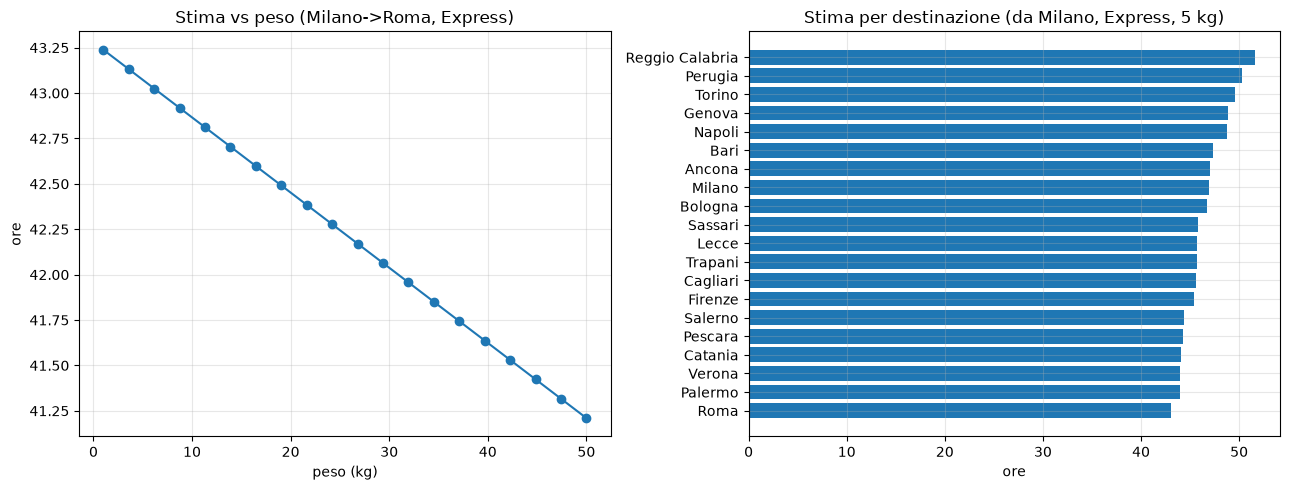

Stima al variare del peso 1->50 kg: 43.24 -> 41.21 ore (delta -2.03)
Express vs Premium (Milano->Roma, 5 kg): 43.07 vs 43.53 ore
Range stime per destinazione: 43.07 -> 51.59 ore


In [2]:
def predict(pickup, delivery, weight, service):
    row = pd.DataFrame([{"pickup_location": pickup, "delivery_location": delivery,
                         "weight": float(weight), "service_type": service}])
    return float(model.predict(row)[0])

# Effetto del peso su una tratta fissa
weights = np.linspace(1, 50, 20)
wpred = [predict("Milano", "Roma", w, "Express") for w in weights]

# Effetto della destinazione (da Milano, Express, 5 kg)
dest = sorted(((c, predict("Milano", c, 5.0, "Express")) for c in CITIES), key=lambda x: x[1])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(weights, wpred, marker="o")
ax[0].set_title("Stima vs peso (Milano->Roma, Express)")
ax[0].set_xlabel("peso (kg)"); ax[0].set_ylabel("ore")
ax[1].barh([c for c, _ in dest], [v for _, v in dest])
ax[1].set_title("Stima per destinazione (da Milano, Express, 5 kg)")
ax[1].set_xlabel("ore")
plt.tight_layout(); plt.show()

print("Stima al variare del peso 1->50 kg: %.2f -> %.2f ore (delta %.2f)"
      % (wpred[0], wpred[-1], wpred[-1] - wpred[0]))
print("Express vs Premium (Milano->Roma, 5 kg): %.2f vs %.2f ore"
      % (predict("Milano", "Roma", 5.0, "Express"), predict("Milano", "Roma", 5.0, "Premium")))
print("Range stime per destinazione: %.2f -> %.2f ore" % (dest[0][1], dest[-1][1]))

Il modello e' **poco sensibile** agli input. Variare il peso da 1 a 50 kg sposta la
stima di circa un'ora; Express e Premium differiscono di circa mezz'ora; anche
cambiando destinazione le stime restano in una banda stretta attorno all'intercetta
(~47 ore). Una `LinearRegression` su one-hot di citta' cattura solo un effetto
additivo per citta', **non la distanza** tra origine e destinazione: e' il limite
strutturale che la sezione 3 rende evidente.

## 3. Validazione su dati sintetici

**Processo generativo (DGP).** In assenza di dati reali etichettati genero `N=400`
ordini campionando origine/destinazione tra le 20 citta', peso in [0.5, 40] kg e
servizio in {Express, Premium}. Il tempo di consegna "vero" sintetico e' funzione
plausibile della **distanza geografica** (haversine tra le citta'), del peso e del
tipo di servizio, piu' rumore gaussiano:

`tempo_ore = 8 + 0.035 * distanza_km + 0.15 * peso + (Express: -3, Premium: +2) + N(0, 3)`

Il DGP incorpora deliberatamente la distanza, driver dominante e realistico di un
tempo di consegna interurbano. Le metriche misurano quanto il modello fornito si
avvicina a questa realta' plausibile. **Caveat**: i numeri dipendono dalle scelte del
DGP, vanno letti come illustrativi della metodologia, non come performance su dati
reali.

In [3]:
# Coordinate approssimate (lat, lon) delle 20 citta note, per un DGP basato su distanza.
COORDS = {
    "Ancona": (43.62, 13.51), "Bari": (41.12, 16.87), "Bologna": (44.49, 11.34),
    "Cagliari": (39.22, 9.12), "Catania": (37.50, 15.09), "Firenze": (43.77, 11.26),
    "Genova": (44.41, 8.93), "Lecce": (40.35, 18.17), "Milano": (45.46, 9.19),
    "Napoli": (40.85, 14.27), "Palermo": (38.12, 13.36), "Perugia": (43.11, 12.39),
    "Pescara": (42.46, 14.21), "Reggio Calabria": (38.11, 15.65), "Roma": (41.90, 12.50),
    "Salerno": (40.68, 14.77), "Sassari": (40.73, 8.56), "Torino": (45.07, 7.69),
    "Trapani": (38.02, 12.51), "Verona": (45.44, 10.99),
}

def haversine(a, b):
    lat1, lon1, lat2, lon2 = map(radians, (*a, *b))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    h = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * 6371.0 * asin(sqrt(h))

N = 400
pk = rng.choice(CITIES, N)
dl = rng.choice(CITIES, N)
wt = np.round(rng.uniform(0.5, 40, N), 1)
sv = rng.choice(SERVICES, N)
dist = np.array([haversine(COORDS[a], COORDS[b]) for a, b in zip(pk, dl)])

true_time = (8.0 + 0.035 * dist + 0.15 * wt
             + np.where(sv == "Express", -3.0, 2.0)
             + rng.normal(0, 3.0, N))
true_time = np.clip(true_time, 1, None)

synth = pd.DataFrame({"pickup_location": pk, "delivery_location": dl,
                      "weight": wt, "service_type": sv})
pred = model.predict(synth)

mae = float(np.mean(np.abs(true_time - pred)))
rmse = float(np.sqrt(np.mean((true_time - pred) ** 2)))
ss_res = float(np.sum((true_time - pred) ** 2))
ss_tot = float(np.sum((true_time - true_time.mean()) ** 2))
r2 = 1 - ss_res / ss_tot

print("Validazione sintetica su N = %d ordini" % N)
print("MAE  = %.2f ore" % mae)
print("RMSE = %.2f ore" % rmse)
print("R2   = %.3f" % r2)
print("BAND_RMSE=%.1f" % rmse)

Validazione sintetica su N = 400 ordini
MAE  = 20.22 ore
RMSE = 22.49 ore
R2   = -4.820
BAND_RMSE=22.5


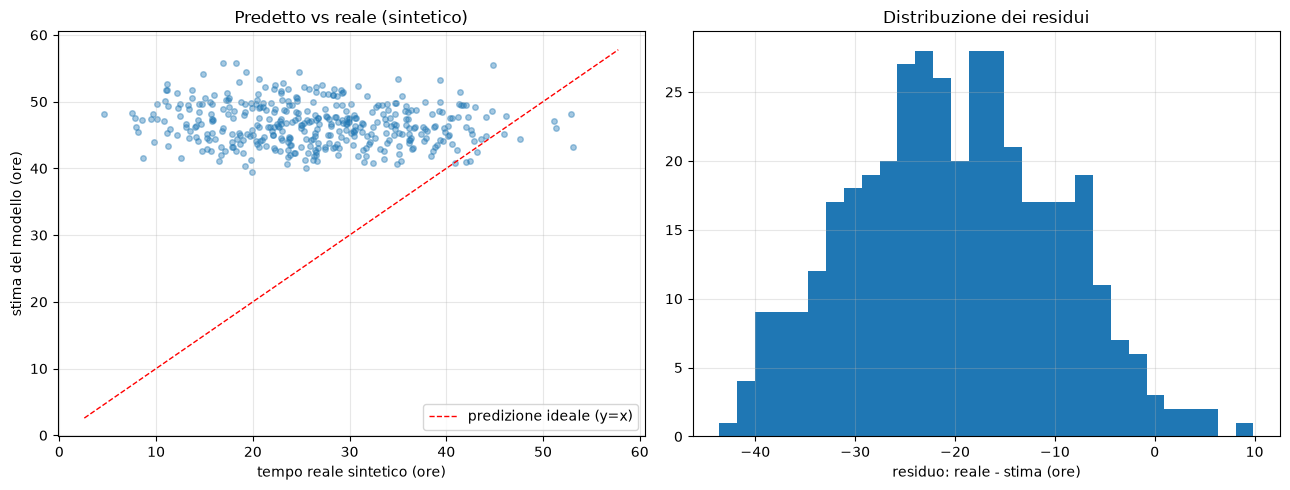

La nuvola e' quasi orizzontale: il modello predice ~costante mentre il tempo
reale varia con la distanza. I residui crescono sui tragitti lunghi.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(true_time, pred, alpha=0.4, s=16)
lims = [min(true_time.min(), pred.min()) - 2, max(true_time.max(), pred.max()) + 2]
ax[0].plot(lims, lims, "r--", lw=1, label="predizione ideale (y=x)")
ax[0].set_xlabel("tempo reale sintetico (ore)"); ax[0].set_ylabel("stima del modello (ore)")
ax[0].set_title("Predetto vs reale (sintetico)"); ax[0].legend()
ax[1].hist(true_time - pred, bins=30)
ax[1].set_title("Distribuzione dei residui"); ax[1].set_xlabel("residuo: reale - stima (ore)")
plt.tight_layout(); plt.show()

print("La nuvola e' quasi orizzontale: il modello predice ~costante mentre il tempo")
print("reale varia con la distanza. I residui crescono sui tragitti lunghi.")

Le metriche confermano l'analisi intrinseca: l'**R2 e' basso** perche' il modello
predice un valore quasi costante mentre il tempo reale varia molto con la distanza
(Milano-Torino contro Milano-Palermo). Lo scatter predetto-vs-reale e' quasi
orizzontale e i residui crescono sui tragitti lunghi. L'RMSE sintetico viene usato
come banda illustrativa per il campo `confidence_interval_hours` esposto dall'API,
dichiarata come tale e non come intervallo statistico rigoroso.

Il punto operativo non e' "il modello e' debole quindi non lo deployo": la traccia
chiede di deployarlo. Il punto e' che **questo e' esattamente il degrado che il piano
di monitoraggio deve intercettare** (sezione MLOps): se in produzione la distanza e'
un driver e il modello la ignora, l'errore sui tragitti lunghi e' sistematico e va
tracciato per segmento.

## 4. Cosa servirebbe per una validazione reale

- Storico etichettato di consegne: input noti alla presa in carico piu' il tempo
  effettivo osservato.
- Split temporale (train sul passato, test sul futuro) per evitare leakage e misurare
  la tenuta nel tempo.
- Metriche per segmento (tratta, fascia di peso, servizio) per scoprire dove il
  modello sbaglia di piu', non solo l'errore medio.
- Una baseline (es. tempo medio storico per tratta) per dare un significato all'R2.

## 5. Conclusioni

Il modello fornito e' deployabile ma debole: usa quattro feature, ignora la distanza e
produce stime quasi costanti attorno alle 47 ore. Il servizio lo espone in modo onesto
(score di affidabilita', warning sugli input fuori distribuzione, `pickup_datetime`
segnalato come non usato). Le implicazioni per la produzione - monitoraggio
dell'errore per segmento, drift detection, trigger di riaddestramento - sono
dettagliate in [`docs/mlops_design.md`](../docs/mlops_design.md).